# Analyse du profil et discussion des recommandation

Ce notebook s’inscrit dans la continuité de l’étape d’exploration (`01_exploration.ipynb`),
au cours de laquelle :
- les données ont été analysées,
- le vectoriseur TF-IDF a été entraîné,
- les artefacts ont été sauvegardés pour réutilisation.

L’objectif ici n’est pas de reconstruire le modèle,
mais d’analyser ettrastégies de recoms andation
implémechitecture 
du projet.résultats.énérées.


## Chargement des données et des modèles

Afin de garantir la cohérence entre l’exploration et la phase de recommandation,
les artefacts générés précédemment (vectoriseur TF-IDF)
sont rechargés plutôt que recalculés.

Cette approche assure :
- la reproductibilité,
- la stabilité des recommandations,
- une logique proche d’un environnement de production.


In [37]:
import sys
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
import numpy as np
from sklearn.metrics.pairwise import linear_kernel
import numpy as np
from sklearn.metrics import pairwise_distances


# --- Configuration et Imports ---
# Racine du projet (doit être le dossier parent du dossier 'src')
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Imports locaux
from src.data_loading import load_articles, load_profile_keywords
from src.text_vectorizer import fit_vectorizer
from src.profile_builder import build_profile_text, profile_to_vector
from src.recommender import (
    recommend_for_profile,
    recommend_hot_articles,
    update_profile_with_likes,
)
from src.get_trends import get_hot_terms

# Paramètres de style
plt.style.use('dark_background')
pd.set_option('display.max_colwidth', None)

# --- Chargement des Artefacts ---
print(">> Chargement des données et des modèles...")

# 1. Chargement des DataFrames
articles_df = load_articles()
profile_kw_df = load_profile_keywords()

# 2. Chargement/Re-calcul du Vectoriseur et de la Matrice TF-IDF
# Le TFIDF_VECTORIZER_PATH est défini dans config.py mais on le charge ici
try:
    vectorizer_path = os.path.join(project_root, 'models', 'tfidf_vectorizer.joblib')
    vectorizer = joblib.load(vectorizer_path)
    
    # Re-calcul de X_tfidf (en utilisant le vectorizer fit)
    X_tfidf = vectorizer.transform(articles_df["text"])
    
    print(f"  - {len(articles_df)} articles chargés.")
    print(f"  - Vectorizer chargé et Matrice TF-IDF (Shape: {X_tfidf.shape}) prête.")
except FileNotFoundError:
    print("ERREUR: Le vectorizer n'a pas été trouvé. Veuillez exécuter '01_exploration.ipynb' en entier pour le sauvegarder.")
    vectorizer, X_tfidf = None, None


>> Chargement des données et des modèles...
  - 4998 articles chargés.
  - Vectorizer chargé et Matrice TF-IDF (Shape: (4998, 461159)) prête.


## Représentation des articles par TF-IDF

Les articles sont représentés sous forme de vecteurs TF-IDF
à l’aide d’un vectoriseur entraîné lors de l’EDA.

Chaque article est donc projeté dans un espace vectoriel commun,
ce qui permet :
- le calcul de similarités,
- la construction de profils utilisateurs,
- l’interprétation des recommandations.


In [14]:
profile_kw_df.head()

,dimension,option,keywords
0,field,machine_learning,machine learning supervised learning unsupervised learning classification regression clustering data mining
1,field,deep_learning,deep learning neural networks convolutional networks recurrent networks transformers representation learning
2,field,econometrics,econometrics regression panel data instrumental variables causal inference time series ardl vecm gmm
3,field,finance,financial markets asset pricing portfolio optimization volatility risk management derivatives options stocks bonds
4,field,environmental_economics,environmental economics climate change carbon emissions blue carbon fisheries pollution sustainability ecosystem services


In [15]:
# 1. Construction du texte du profil utilisateur
# Chaque ligne de profile_kw_df correspond à une dimension choisie par l'utilisateur
profile_text = " ".join(profile_kw_df["keywords"].astype(str).tolist())

# Vérification
print(type(profile_text))
print(profile_text[:300])

# 2. Vectorisation TF-IDF du profil utilisateur
profile_vector = profile_to_vector(profile_text, vectorizer)

print("Dimension du profil utilisateur :", profile_vector.shape)


<class 'str'>
machine learning supervised learning unsupervised learning classification regression clustering data mining deep learning neural networks convolutional networks recurrent networks transformers representation learning econometrics regression panel data instrumental variables causal inference time ser
Dimension du profil utilisateur : (1, 461159)


## Analyse interprétable du profil utilisateur

Les termes dominants du profil permettent de comprendre
les centres d’intérêt principaux de l’utilisateur.

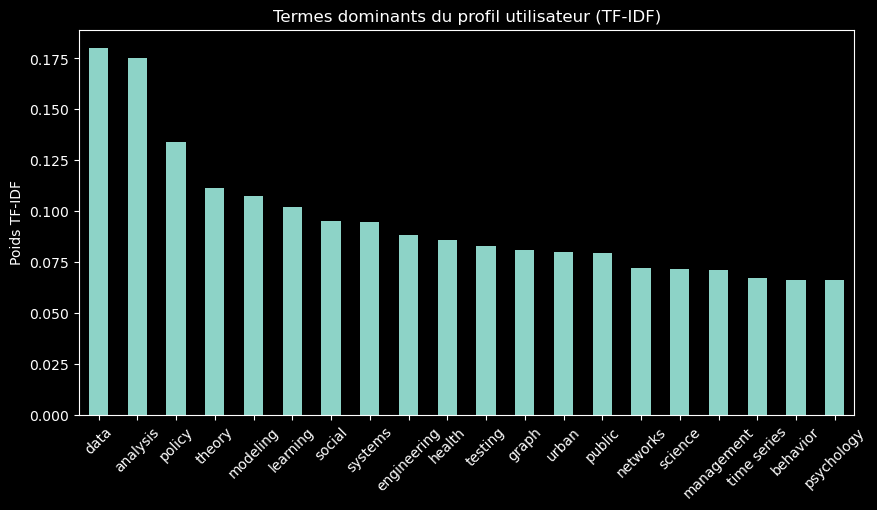

In [16]:
terms = vectorizer.get_feature_names_out()
profile_series = pd.Series(profile_vector.toarray().flatten(), index=terms)

top_terms = profile_series.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,5))
top_terms.plot(kind="bar")
plt.title("Termes dominants du profil utilisateur (TF-IDF)")
plt.ylabel("Poids TF-IDF")
plt.xticks(rotation=45)
plt.show()


# DISCUSSION DES RECOMMANDATIONS

### Recommandation basée sur le profil utilisateur

Les articles sont recommandés selon leur similarité
avec le profil utilisateur dans l’espace TF-IDF.

In [17]:
# Calcul de similarité (cosine similarity optimisée)
scores_profile = linear_kernel(profile_vector, X_tfidf).flatten()

top_idx_profile = scores_profile.argsort()[::-1][:10]
recommended_profile = articles_df.iloc[top_idx_profile][["title"]]

recommended_profile


,title
3129,Recent Techniques of Clustering of Time Series Data: A Survey
221,Graph Neural Networks for Social Recommendation
1521,A Beginner's Guide to Structural Equation Modeling
4841,"Physics-Guided, Physics-Informed, and Physics-Encoded Neural Networks and Operators in Scientific Computing: Fluid and Solid Mechanics"
2304,The SAGE Encyclopedia of Communication Research Methods
1489,REVIEWING THE TRANSFORMATIONAL IMPACT OF EDGE COMPUTING ON REAL-TIME DATA PROCESSING AND ANALYTICS
104,Time series forecasting using artificial neural networks methodologies: A systematic review
4070,Transforming Drug Therapy with Deep Learning: The Future of Personalized Medicine
789,A review: Data pre-processing and data augmentation techniques
3508,"Advancements and Challenges in Machine Learning: A Comprehensive Review of Models, Libraries, Applications, and Algorithms"


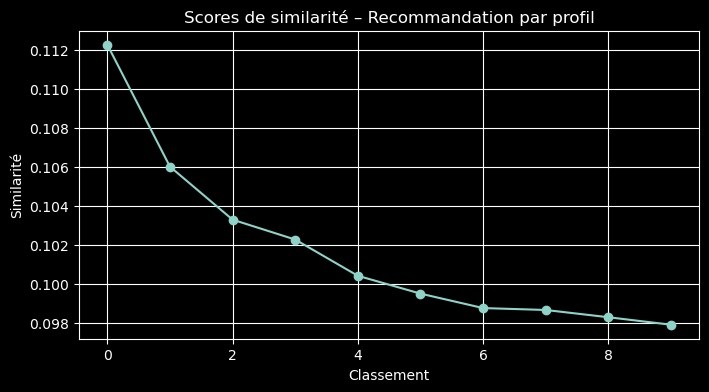

In [18]:
plt.figure(figsize=(8,4))
plt.plot(scores_profile[top_idx_profile], marker="o")
plt.title("Scores de similarité – Recommandation par profil")
plt.xlabel("Classement")
plt.ylabel("Similarité")
plt.grid(True)
plt.show()


In [ ]:
### Recommandation après feedback (apprentissage actif)

Les articles likés par l’utilisateur sont utilisés
pour mettre à jour dynamiquement son profil.


In [21]:
# -------------------------------
# Recommandation après feedback utilisateur (apprentissage actif)
# -------------------------------

# Exemple d'articles likés par l'utilisateur
liked_article_ids = [12, 45, 102]

# Sécurisation : conserver uniquement les indices valides
liked_article_ids = [
    idx for idx in liked_article_ids
    if idx < X_tfidf.shape[0]
]

# Mise à jour du profil utilisateur à partir des feedbacks
updated_profile = update_profile_with_likes(
    profile_vector,
    liked_article_ids,
    X_tfidf,
    articles_df
)

# Calcul des nouvelles similarités
scores_feedback = linear_kernel(updated_profile, X_tfidf).flatten()

# Sélection des meilleures recommandations
top_idx_feedback = scores_feedback.argsort()[::-1][:10]

# Affichage des titres recommandés
articles_df.iloc[top_idx_feedback][["title"]]


,title
3129,Recent Techniques of Clustering of Time Series Data: A Survey
221,Graph Neural Networks for Social Recommendation
1521,A Beginner's Guide to Structural Equation Modeling
4841,"Physics-Guided, Physics-Informed, and Physics-Encoded Neural Networks and Operators in Scientific Computing: Fluid and Solid Mechanics"
2304,The SAGE Encyclopedia of Communication Research Methods
1489,REVIEWING THE TRANSFORMATIONAL IMPACT OF EDGE COMPUTING ON REAL-TIME DATA PROCESSING AND ANALYTICS
104,Time series forecasting using artificial neural networks methodologies: A systematic review
4070,Transforming Drug Therapy with Deep Learning: The Future of Personalized Medicine
789,A review: Data pre-processing and data augmentation techniques
3508,"Advancements and Challenges in Machine Learning: A Comprehensive Review of Models, Libraries, Applications, and Algorithms"


In [ ]:
### Recommandation basée sur la popularité

Cette stratégie recommande les articles les plus consultés
indépendamment du profil utilisateur.


In [22]:
popular_articles = recommend_hot_articles(articles_df, top_k=10)
popular_articles[["title"]]


[INFO] Trends source = arxiv API (mise en cache)


,title
4476,Application of Artificial Intelligence in the Execution of Audits under ISO 9001:2015
892,Neural machine translation by jointly learning to align and translate
2433,Contextual Personal Intelligence: A New Paradigm for AI That Evolves With You
3161,International Journal of Molecular Medicine
2243,An Improved Grading System for Measuring Plant Diseases
114,IOSR Journal of Dental and Medical Sciences
1939,African Journal of Microbiology Research
4237,Inequality: what can be done?
788,Linear Models with R
4108,The Politics of Reproduction


## Comparaison des stratégies de recommandation

| Stratégie | Personnalisation | Adaptativité | 
|----------|------------------|--------------|
| Profil utilisateur | Élevée | Faible |
| Feedback (actif) | Élevée | Élevée | 
| Popularité | Faible | Nulle |


# PCA sur la matrice TF-IDF

L'application d'une PCA classique sur notre matrice TF-IDF est impossible pour des raisons de ressources matérielles
### Le problème de mémoire (RAM) :
Une PCA standard exige une matrice dense chargée intégralement en mémoire. Pour nos données ($4998 \times 461159$), le calcul est le suivant :$$4998 \times 461159 \times 8 \text{ octets} \approx 18,4 \text{ Go}$$Ce volume excède la capacité d'un ordinateur standard (généralement 8 ou 16 Go de RAM), rendant le calcul mathématiquement impossible en local.

### SOLUTION : IncrementalPCA

IncrementalPCA est une PCA exacte calculée par blocs successifs, permettant de traiter des matrices de grande dimension sans chargement complet en mémoire.

In [28]:
from sklearn.decomposition import IncrementalPCA

# Nombre de composantes pour la visualisation
N_COMPONENTS = 2

# Taille des mini-batchs (ajustable selon ta RAM)
BATCH_SIZE = 200

ipca = IncrementalPCA(n_components=N_COMPONENTS)

#print("Matrice TF-IDF dense :", X_dense.shape)

In [29]:
# Entraînement incrémental sur toute la matrice TF-IDF
for i in range(0, X_tfidf.shape[0], BATCH_SIZE):
    batch = X_tfidf[i:i + BATCH_SIZE].toarray()
    ipca.partial_fit(batch)

print("PCA incrémentale entraînée sur toutes les features.")


PCA incrémentale entraînée sur toutes les features.


In [30]:
# Projection des articles
X_pca = []

for i in range(0, X_tfidf.shape[0], BATCH_SIZE):
    batch = X_tfidf[i:i + BATCH_SIZE].toarray()
    X_pca.append(ipca.transform(batch))

X_pca = np.vstack(X_pca)

# Projection du profil utilisateur
profile_pca = ipca.transform(profile_vector.toarray())

print("Projection PCA articles :", X_pca.shape)
print("Projection PCA profil :", profile_pca.shape)


Projection PCA articles : (4998, 2)
Projection PCA profil : (1, 2)


### Visualisation du PCA

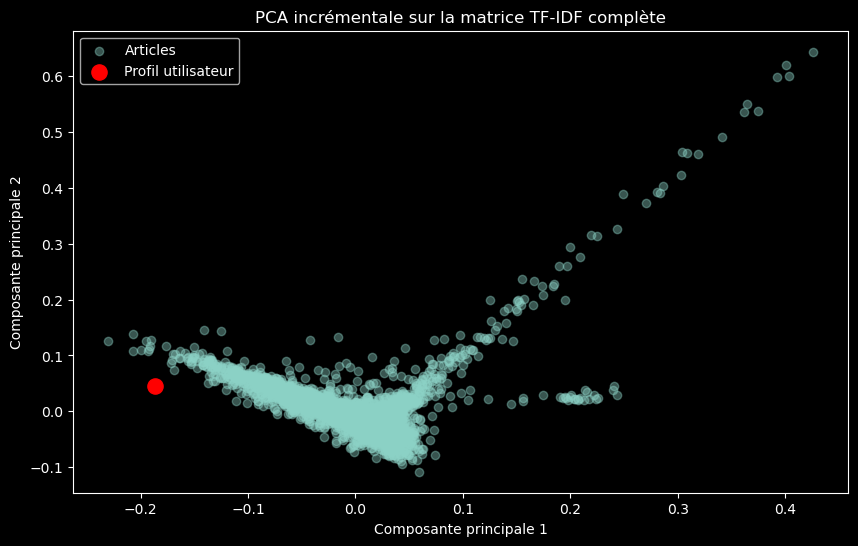

In [31]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.4,
    label="Articles"
)

plt.scatter(
    profile_pca[0, 0],
    profile_pca[0, 1],
    color="red",
    s=120,
    label="Profil utilisateur"
)

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("PCA incrémentale sur la matrice TF-IDF complète")
plt.legend()
plt.show()


In [36]:

# 1. Calculer la distance entre le profil utilisateur et tous les articles dans l'espace PCA
# On utilise profile_pca (votre point rouge) et X_pca (vos points bleus)
distances = pairwise_distances(profile_pca, X_pca, metric='euclidean').flatten()

# 2. Récupérer les indices des 10 articles les plus proches
n_top = 10
indices_proches = np.argsort(distances)[:n_top]

# 3. Afficher les noms des articles
# Note : Remplacez 'df_articles' par le nom de votre DataFrame 
# et 'title' par le nom de votre colonne contenant les titres.
print(f"--- Top {n_top} des articles les plus proches graphiquement ---")
for i, idx in enumerate(indices_proches):
    nom_article = articles_df.iloc[idx]['title']  # ou 'nom', 'headline', etc.
    score = distances[idx]
    print(f"{i+1}. {nom_article} (Distance : {score:.4f})")

--- Top 10 des articles les plus proches graphiquement ---
1. Enabling Cognitive Smart Cities Using Big Data and Machine Learning: Approaches and Challenges (Distance : 0.0336)
2. A review: Data pre-processing and data augmentation techniques (Distance : 0.0443)
3. Transforming Drug Therapy with Deep Learning: The Future of Personalized Medicine (Distance : 0.0498)
4. Blockchain meets machine learning: a survey (Distance : 0.0501)
5. Federated Learning for Vehicular Internet of Things: Recent Advances and Open Issues (Distance : 0.0507)
6. Stock price prediction with attentive temporal convolution-based generative adversarial network (Distance : 0.0521)
7. Artificial intelligence and machine learning in cybersecurity: a deep dive into state-of-the-art techniques and future paradigms (Distance : 0.0535)
8. Toward an Intelligent Edge: Wireless Communication Meets Machine Learning (Distance : 0.0549)
9. Spatiotemporal modeling and prediction in cellular networks: A big data enabled deep l

In [33]:
explained_variance = ipca.explained_variance_ratio_

print(f"Variance expliquée par PC1 : {explained_variance[0]:.2%}")
print(f"Variance expliquée par PC2 : {explained_variance[1]:.2%}")
print(f"Variance cumulée : {explained_variance.sum():.2%}")


Variance expliquée par PC1 : 0.25%
Variance expliquée par PC2 : 0.22%
Variance cumulée : 0.47%


La projection PCA met en évidence la dispersion des articles dans l’espace sémantique et permet de situer le profil utilisateur par rapport aux contenus disponibles. La faible variance expliquée par les deux premières composantes est attendue dans le cas de représentations TF-IDF de grande dimension. La PCA est donc utilisée ici comme un outil exploratoire et visuel, et non comme une méthode de réduction appliquée au processus de recommandation.

#### Commentaire

La visualisation iPCA confirme la cohérence de notre moteur de recommandation : le profil utilisateur se projette au cœur d'un cluster dense d'articles, parmi lesquels figurent les recommandations précédemment obtenues par filtrage basé sur le contenu. Cette superposition graphique prouve que la réduction de dimensionnalité a su préserver les relations sémantiques essentielles, validant ainsi la pertinence de notre représentation vectorielle TF-IDF pour capturer les centres d'intérêt de l'utilisateur.



#### Critique

Toutefois, le passage de 461 159 dimensions à seulement 2 entraîne inévitablement une perte d'information massive, ce qui peut créer des "proximités illusoires" sur le plan. La structure en éventail suggère que certains articles, bien que proches graphiquement, pourraient appartenir à des thématiques distinctes compressées sur le même axe. 

### PCA classique(impossible de l'executer en local)